In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from transformers import AutoTokenizer


def plot_attribution(
    attribution_csv_path: str,
    prompt_json_path: str,
    model_name: str,
    attribution_column: str = "soft_nc",
):
    # -------------------------
    # Load Data
    # -------------------------
    df = pd.read_csv(attribution_csv_path)
    with open(prompt_json_path, "r") as f:
        prompt_data = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Generated tokens only
    source_len = prompt_data["source_len"]
    full_ids = prompt_data["generated_ids"]
    gen_ids = full_ids[source_len:]

    tokens = tokenizer.convert_ids_to_tokens(gen_ids)

    values = df[attribution_column].values

    # -------------------------
    # Normalize for coloring
    # -------------------------
    norm = Normalize(vmin=np.min(values), vmax=np.max(values))

    # -------------------------
    # Create Figure
    # -------------------------
    fig = plt.figure(figsize=(max(12, len(tokens)*0.8), 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

    # =========================
    # Heatmap of Attribution
    # =========================
    ax0 = fig.add_subplot(gs[0])

    heat = np.expand_dims(values, axis=0)
    im = ax0.imshow(heat, aspect="auto", cmap="viridis", norm=norm)

    ax0.set_xticks(range(len(tokens)))
    ax0.set_xticklabels(tokens, rotation=45, ha="right", fontsize=10)
    ax0.set_yticks([])

    ax0.set_title(f"Attribution Heatmap ({attribution_column})")

    cbar = plt.colorbar(im, ax=ax0, orientation="vertical")
    cbar.set_label("Attribution Strength")

    # =========================
    # Probability Change Curve
    # =========================
    ax1 = fig.add_subplot(gs[1])

    ax1.plot(df["dPR"], marker="o", label="dPR")
    ax1.plot(df["dPnotR"], marker="o", label="dPnotR")
    ax1.set_xticks(range(len(tokens)))
    ax1.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax1.set_ylabel("Probability Change")
    ax1.set_title("Probability Effects")
    ax1.legend()

    plt.tight_layout()
    plt.show()

/opt/homebrew/Caskroom/miniforge/base/envs/pwm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


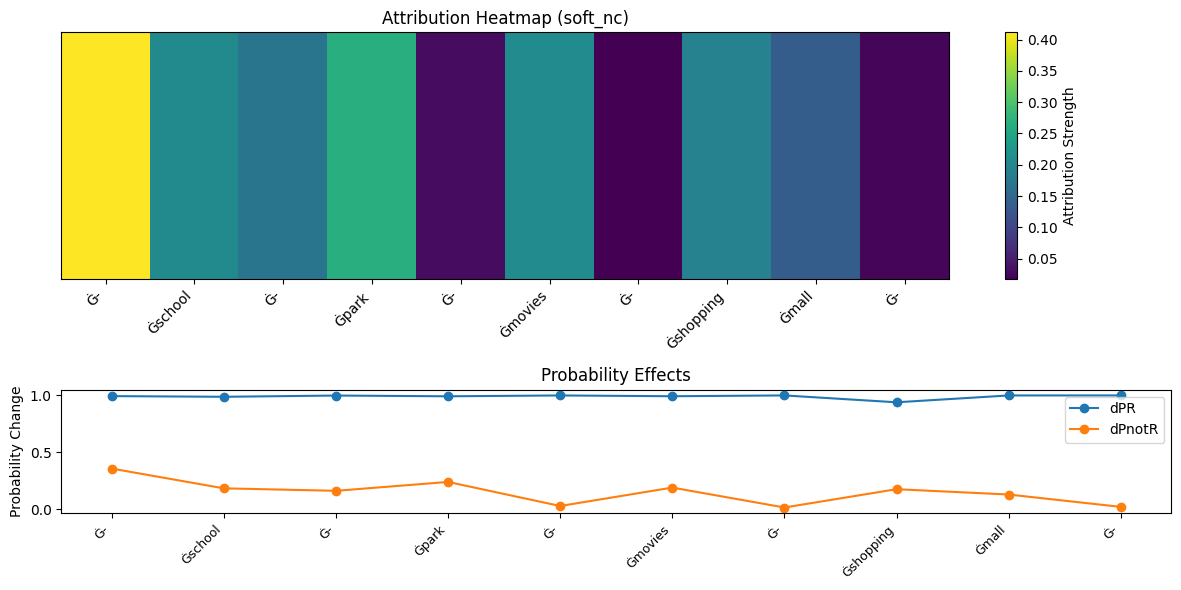

In [8]:
plot_attribution(
    attribution_csv_path="../outputs/qwen_qwen2-1.5b/tellmewhy/prompts/prompt_000/deeplift2_dimred_factoranalysis1_steps.csv",
    prompt_json_path="../outputs/qwen_qwen2-1.5b/tellmewhy/prompts/prompt_000/debug.json",
    model_name="Qwen/Qwen2-1.5B",
    attribution_column="soft_nc",  # oder dPnotR
)